## Instalação

In [ ]:
%pip uninstall -y google-ai-generativelanguage google-generativeai langchain-google-genai
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai
%pip install -U langchain
%pip install -U langchain-pinecone
%pip install -U langchain-community
%pip install -U langgraph
%pip install arxiv

Found existing installation: google-ai-generativelanguage 0.6.15
Uninstalling google-ai-generativelanguage-0.6.15:
  Successfully uninstalled google-ai-generativelanguage-0.6.15
Found existing installation: langchain-google-genai 4.2.7
Uninstalling langchain-google-genai-4.2.7:
  Successfully uninstalled langchain-google-genai-4.2.7
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl (1.3 MB)


  Using cached langchain_google_genai-4.2.7-py3-none-any.whl.metadata (2.7 kB)
Using cached langchain_google_genai-4.2.7-py3-none-any.whl (70 kB)


## Aula 1


In [ ]:
import os
from google.colab import userdata
api_key = userdata.get('Gemni_Alura')
os.environ['GOOGLE_API_KEY'] = api_key

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [ ]:
from langchain_core.prompts import PromptTemplate

In [ ]:
modelo_de_prompt = PromptTemplate(template= "Fale um pouco sobre {pais}",
                                  input_variables= ['pais'])

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
cadeia = modelo_de_prompt | llm | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'pais' : 'Andorra'})

In [ ]:
print(resposta)

Andorra é um país fascinante e único, muitas vezes chamado de "o segredo bem guardado" dos Pirenéus. Localizado exatamente na fronteira entre a **Espanha e a França**, este pequeno principado tem características que o tornam muito diferente de qualquer outro lugar na Europa.

Aqui estão alguns pontos principais para conhecer Andorra:

### 1. Geografia e Natureza
*   **Nos Pirenéus:** O país é inteiramente montanhoso. A altitude média é a mais alta da Europa, o que significa paisagens deslumbrantes de vales profundos e picos nevados.
*   **Paraíso do Esqui:** Durante o inverno, o país se transforma em um dos principais destinos de esqui do sul da Europa. Estações como **Grandvalira** e **Vallnord** são famosas internacionalmente.
*   **Verão:** Quando a neve derrete, o país se torna um destino excelente para caminhadas, ciclismo de montanha e turismo de aventura.

### 2. Sistema Político Único (Coprincipado)
Andorra possui um sistema de governo raríssimo no mundo: é um **coprincipado pa

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

/tmp/ipykernel_1435/2584200377.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [ ]:
os.environ['TAVILY_API_KEY'] = userdata.get('tavily-api')

In [ ]:
@tool
def busca_web(query: str) -> list:
  """
  Busca na web por um termo especifico
  """
  tavily_search = TavilySearchResults(max_results=2, search_depth= "advanced", max_tokens= 1000)
  resultado_busca = tavily_search.invoke(query)
  return resultado_busca
busca_web.invoke('Itaberaí')

/tmp/ipykernel_1435/1668289903.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=2, search_depth= "advanced", max_tokens= 1000)


[{'title': 'Itaberaí – Wikipédia, a enciclopédia livre',
  'url': 'https://pt.wikipedia.org/wiki/Itabera%C3%AD',
  'content': 'Itaberaí é um município brasileiro "Município (Brasil)") do interior do estado de Goiás, Região Centro-Oeste do país, localizado na região intermediária de Goinia. Sua distncia até a capital estadual, Goinia, é de 92 km. Sua população estimada em 2020 foi de 43.622 habitantes, estando na posição 785 das cidades mais populosas do país conforme estatísticas do Instituto Brasileiro de Geografia e Estatística (IBGE).\n\n## História\n\n[editar | editar código]\n\n Fundação: 9 de novembro de 1868 (157 anos)\n\nA antiga Curralinho, hoje Itaberaí, nasceu pelo desbravamento do Capitão-Mor Salvador Pedroso de Campos. Às margens do rio das Pedras criou gado. De seu leito extraiu ouro. [...] Corre sobre um leito inteiramente permeável e coberto de seixos, num percurso total de trinta e seis quilômetros, a contar de sua cabeceira a barra. Nasce na fazenda Santa Maria, próxi

In [ ]:
busca_web.invoke('Itaberaí')

[{'title': 'Itaberaí – Wikipédia, a enciclopédia livre',
  'url': 'https://pt.wikipedia.org/wiki/Itabera%C3%AD',
  'content': 'Itaberaí é um município brasileiro "Município (Brasil)") do interior do estado de Goiás, Região Centro-Oeste do país, localizado na região intermediária de Goinia. Sua distncia até a capital estadual, Goinia, é de 92 km. Sua população estimada em 2020 foi de 43.622 habitantes, estando na posição 785 das cidades mais populosas do país conforme estatísticas do Instituto Brasileiro de Geografia e Estatística (IBGE).\n\n## História\n\n[editar | editar código]\n\n Fundação: 9 de novembro de 1868 (157 anos)\n\nA antiga Curralinho, hoje Itaberaí, nasceu pelo desbravamento do Capitão-Mor Salvador Pedroso de Campos. Às margens do rio das Pedras criou gado. De seu leito extraiu ouro. [...] Corre sobre um leito inteiramente permeável e coberto de seixos, num percurso total de trinta e seis quilômetros, a contar de sua cabeceira a barra. Nasce na fazenda Santa Maria, próxi

In [ ]:
tools = [busca_web]

In [ ]:
llm_com_ferramenta = llm.bind(tools= tools)

In [ ]:
modelo_de_prompt = PromptTemplate(template= "Fale um pouco sobre {pais}",
                                  input_variables= ['pais'])

In [ ]:
cadeia = modelo_de_prompt | llm_com_ferramenta | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'pais' : 'Andorra'})

In [ ]:
prompt = """
Usando apenas suas ferrramentas me fale sobre sao tome e principe
"""

In [ ]:
resposta = llm_com_ferramenta.invoke(prompt)


In [ ]:
print(resposta)

content=[] additional_kwargs={'function_call': {'name': 'busca_web', 'arguments': '{"query": "informa\\u00e7\\u00f5es gerais sobre S\\u00e3o Tom\\u00e9 e Pr\\u00edncipe"}'}, '__gemini_function_call_thought_signatures__': {'qQmIxzcK': 'EjQKMgERTTIPnq+/hymjWbkJ2+Qrk71qw1Op6RZnKtUYWYDga8wJk0IT3FcK/XFhJL0bjKLt'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f65df-7c7d-7560-9587-fd37eed97df3-0' tool_calls=[{'name': 'busca_web', 'args': {'query': 'informações gerais sobre São Tomé e Príncipe'}, 'id': 'qQmIxzcK', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 85, 'output_tokens': 24, 'total_tokens': 109, 'input_token_details': {'cache_read': 0}}


In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent

In [ ]:
system_prompt = """ Atue como um assitente útil.
Use as ferramentas fornecidas para responder às perguntas do usuário.
- busca_web: retorna os resultados de uma busca na web
Use a busca_web sempre que um usuário fizer uma pergunta sobre um tema especifico e retorne o link dos artigos na resposta
"""

In [ ]:
agente_web = create_agent(model= llm, tools= tools, system_prompt= system_prompt)

In [ ]:
resultado = agente_web.invoke({"messages" : [("user", "Fale sobre o Camboja")]})

In [ ]:
print(resultado)

{'messages': [HumanMessage(content='Fale sobre o Camboja', additional_kwargs={}, response_metadata={}, id='87a85e55-4b77-4cbe-a89e-f640a0ae9169'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'busca_web', 'arguments': '{"query": "resumo sobre o Camboja hist\\u00f3ria cultura e turismo"}'}, '__gemini_function_call_thought_signatures__': {'H96YcjUe': 'EjQKMgERTTIPjocc3L/WWbZpci5/eS0nI+H6HI/CqSrgDUE0ZPMNJK1QJ9xx3O5J+wFpV426'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f65df-81f2-77e0-808c-8f4988eef30c-0', tool_calls=[{'name': 'busca_web', 'args': {'query': 'resumo sobre o Camboja história cultura e turismo'}, 'id': 'H96YcjUe', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 117, 'output_tokens': 25, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='[{"title": "Camboja: dados, mapa, bandeira

In [ ]:
resultado['messages'][-1]

AIMessage(content=[{'type': 'text', 'text': 'O Camboja é um país fascinante localizado no Sudeste Asiático, conhecido por sua história milenar, templos impressionantes e uma cultura resiliente. Aqui estão os principais pontos para entender o país:\n\n### 1. Geografia e Capital\n*   **Capital:** Phnom Penh.\n*   **Clima:** Tropical monçônico, marcado por temperaturas elevadas e períodos de chuva.\n*   **Geografia:** É caracterizado por planícies centrais, cercadas por montanhas, e cortado pelo importante rio Mekong, que exerce um papel vital na agricultura e na vida da população.\n\n### 2. Cultura e Religião\n*   A religião predominante é o **Budismo Theravada**, que influencia profundamente o estilo de vida, as artes e a arquitetura do país.\n*   A cultura cambojana é rica em festivais, danças tradicionais e uma culinária que mistura sabores locais com influências históricas, inclusive da colonização francesa.\n\n### 3. Economia\n*   A economia baseia-se principalmente no **setor terci

In [ ]:
%pip uninstall -y arxiv
%pip install "arxiv<2.0" -q

Found existing installation: arxiv 4.0.0
Uninstalling arxiv-4.0.0:
  Successfully uninstalled arxiv-4.0.0
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
pip show arxiv

Name: arxiv
Version: 1.4.8
Summary: Python wrapper for the arXiv API: http://arxiv.org/help/api/
Home-page: https://github.com/lukasschwab/arxiv.py
Author: Lukas Schwab
Author-email: lukas.schwab@gmail.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: feedparser
Required-by: 


In [ ]:
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun
import arxiv

In [ ]:
import arxiv

# Força a URL base da API para HTTPS
arxiv.Client.query_url_format = arxiv.Client.query_url_format.replace("http://", "https://")

print(arxiv.Client.query_url_format)  # deve mostrar https://export.arxiv.org/api/query?


https://export.arxiv.org/api/query?{}


In [ ]:
# 1. Monkeypatch (roda uma vez, define a substituição)
import arxiv
import urllib.request

_original_urlopen = urllib.request.urlopen

def _urlopen_https(url, *args, **kwargs):
    if isinstance(url, str) and url.startswith("http://export.arxiv.org"):
        url = url.replace("http://", "https://", 1)
    elif hasattr(url, "full_url") and url.full_url.startswith("http://export.arxiv.org"):
        url.full_url = url.full_url.replace("http://", "https://", 1)
    return _original_urlopen(url, *args, **kwargs)

urllib.request.urlopen = _urlopen_https

# 2. Daqui pra frente, tudo que usar urlopen já sai em https automaticamente
arxiv_wrapper = ArxivAPIWrapper(top_k_results=3, doc_content_chars=300)
tool_cientifica = ArxivQueryRun(arxiv_wrapper=arxiv_wrapper)
agente_cientifico = create_agent(model= llm, tools = [tool_cientifica], system_prompt= system_prompt_2)

resultado = agente_cientifico.invoke({"messages": [("user", "AI impact in agriculture")]})

In [ ]:
resultado['messages'][-1]

AIMessage(content=[{'type': 'text', 'text': 'O impacto da Inteligência Artificial na agricultura é um campo em rápida evolução, focado principalmente em aumentar a eficiência e reduzir a complexidade das operações agrícolas.\n\nCom base em pesquisas recentes encontradas no arXiv, aqui estão alguns destaques sobre como a IA está sendo aplicada neste setor:\n\n*   **Planejamento de Missões Robóticas e Agricultura de Precisão:** Pesquisas atuais exploram o uso de Modelos de Linguagem de Grande Escala (LLMs) para permitir que agricultores (mesmo aqueles sem conhecimento técnico em programação) controlem robôs heterogêneos usando linguagem natural. Isso facilita a execução de tarefas complexas de manipulação e visão computacional no campo, tornando a tecnologia mais acessível.\n\n**Artigo relevante encontrado:**\n*   *"One For All: LLM-based Heterogeneous Mission Planning in Precision Agriculture"* (Marcos Abel Zuzuárregui, Mustafa Melih Toslak, Stefano Carpin)\n\nAlém desse foco específico

In [ ]:
from typing import TypedDict

In [ ]:
class AgentState(TypedDict):
  user_query : str
  web_answer : str
  scientific_answer : str
  final_answer : str

In [ ]:
def funcao_agente_web(state : AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza na web a busca por um termo esoecifico.

  Essa função pega o estado atual do agente (que contém a pergunta do usuário) ecria um agente usando o Gemini e a ferramenta Tavily e retorna  a repsota do agente.

  Args:
    state: (AgentState) - Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
    (str) - A resposta do agente.
  """
  system_prompt = """ Atue como um assitente útil.
  Use as ferramentas fornecidas para responder às perguntas do usuário.
  - busca_web: retorna os resultados de uma busca na web
  Use a busca_web sempre que um usuário fizer uma pergunta sobre um tema especifico e retorne o link dos artigos na resposta
  """
  agente_web = create_agent(model= llm, tools= tools, system_prompt= system_prompt)
  resultado = agente_web.invoke({"messages" : [("user", state["user_query"])]})
  resposta_final = resultado['messages'][-1].content[0]['text']
  return {"web_answer" : resposta_final}

In [ ]:
def funcao_agente_cientifico(state : AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza uma busca no arxiv por um termo especifico.

  Essa função pega o estado atual do agente (que contém a pergunta do usuário) ecria um agente usando o Gemini e a ferramenta arxiv e retorna  a resposta do agente.

  Args:
    state: (AgentState) - Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
    (str) - A resposta do agente.
  """
  system_prompt =  """ Atue como um assitente útil.

Use as ferramentas fornecidas para responder às perguntas do usuário.

- tool_cientifica: retorna os resultados de uma busca no arxiv

Use a tool_cientifica sempre que um usuário fizer uma pergunta sobre um tema especifico e retorne o titulo dos artigos

"""
  agente_cientifico = create_agent(model= llm, tools = [tool_cientifica], system_prompt= system_prompt)
  resultado = agente_cientifico.invoke({"messages" : [("user", state["user_query"])]})
  resposta_final = resultado['messages'][-1].content[0]['text']
  return {"scientific_answer" : resposta_final}

In [ ]:
from langgraph.graph import START, StateGraph, END

In [ ]:
workflow = StateGraph(AgentState)

In [ ]:
workflow.add_node('agente_web', funcao_agente_web)
workflow.add_edge(START, 'agente_web')
workflow.add_edge('agente_web', END)

app = workflow.compile()

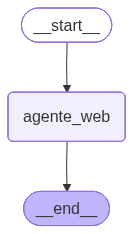

In [ ]:
from IPython.display import Image, display

Image(app.get_graph().draw_mermaid_png())

In [ ]:
resultado = app.invoke({"user_query" : "Qual as principais fontes economicas da Moldávia?"})

In [ ]:
print(resultado["web_answer"])

A economia da Moldávia é caracterizada por ser fortemente dependente do setor agrícola e de serviços, enfrentando desafios estruturais como a escassez de recursos energéticos próprios.

Aqui estão os principais pilares da economia moldava:

### 1. Agronegócio (Base da Economia)
Devido ao seu clima favorável e solos férteis, a agricultura é o setor fundamental do país. A Moldávia é mundialmente reconhecida pela sua produção vitivinícola.
*   **Vinho:** É o produto de exportação mais icônico do país. A cultura do vinho está profundamente enraizada na economia e na identidade nacional.
*   **Produtos:** Além do vinho, o país produz e exporta frutas, hortaliças, grãos e tabaco.

### 2. Setor de Serviços
Desde a independência após o colapso da União Soviética, o setor de serviços cresceu significativamente, passando a representar a maior parcela do Produto Interno Bruto (PIB) do país (estimado em mais de 60%).

### 3. Indústria
A indústria moldava é focada principalmente no processamento de

In [ ]:
def supervisor_node(state : AgentState) -> dict:
  """
  Combina os resultados da web e de agentes cientifcos e formata a resposta final.

  Args:
    state (AgentState) - O estado atual do agente, contendo web_answer e scientific_answer.

  Returns:
    (str) - AUm dicionário com a resposta final combinada e formatada.
  """
  web_results = state.get("web_answer", "Não foi realizada busca na Web")
  scientific_results = state.get("scientific_answer", "Não foi realizada pesquisa cientifica")

  final_answer = "## Resultados de pesquisa combinados\n\n"
  final_answer += "## Resultados de pesquisa na Web\n"
  final_answer += web_results
  final_answer += "\n\n"
  final_answer += "## Resultados de pesquisa cientifica\n"
  final_answer += scientific_results

  return {"final_answer" : final_answer}

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'web_search')
workflow.add_edge('web_search', 'scientific_search')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

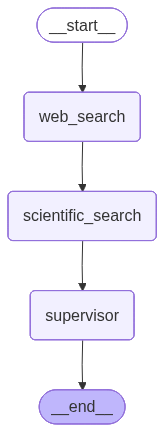

In [ ]:
Image(app.get_graph().draw_mermaid_png())

In [ ]:
resultado = app.invoke({"user_query" : "Qual as principais fontes economicas da Moldávia?"})
print(resultado["final_answer"])

## Resultados de pesquisa combinados

## Resultados de pesquisa na Web
A economia da Moldávia é historicamente baseada no agronegócio, dado o seu clima favorável e solos férteis. Abaixo, detalho as principais fontes econômicas e características do país:

### 1. Agronegócio e Indústria de Alimentos
Este é o pilar da economia moldava. O país é um importante produtor e exportador de produtos agrícolas.
*   **Vitivinicultura (Vinhos):** É um dos setores mais tradicionais e renomados. A Moldávia é conhecida por sua vasta produção de vinhos, sendo uma das suas maiores exportações.
*   **Produção Agrícola:** Destacam-se o cultivo de frutas, hortaliças, grãos e tabaco.

### 2. Setor de Serviços
Desde o colapso da União Soviética, o setor de serviços cresceu significativamente e hoje representa a maior parte do Produto Interno Bruto (PIB) do país (estimado em cerca de 60-65%). Isso reflete a modernização da economia e a mudança estrutural em relação ao período soviético, onde a indústria e a ag

In [ ]:
def router_agent(state : AgentState) -> dict:
  """
  Agente roteador que decide qual ferramenta usar(busca web ou busa cientifica)
  com base na pergunta do usuário com um agente React interno.
  """
  router_prompt = """
  Você é um agente roteador sua tarefa é decidir qual agente usar para responder a uma pergunta do usuário.

  Pergunta do usuário: {user_query}

  Você pode escolher entre as seguintes ferramentas:

  - tool_cientifica: retorna os resultados de uma busca no arxiv:
  Use a tool_cientifica sempre que um usuário fizer uma pergunta sobre um tema especifico e retorne o titulo dos artigos
  - busca_web: retorna os resultados de uma busca na web:
  Use a busca_web sempre que um usuário fizer uma pergunta sobre um tema especifico e retorne o link dos artigos na resposta

  Responda apenas com o nome da ferramenta escolhida (web_search o u scientific_search)
  """
  router_agent_instance = create_agent(model= llm,tools=[], system_prompt= router_prompt)
  response = router_agent_instance.invoke({"messages" : [("user", state["user_query"])]})

  decision = response['messages'][-1].content[0]['text'].strip().lower()
  if 'web_search' in decision:
    return {"router_decision" : 'web_search'}
  elif 'scientific_search' in decision:
    return {"router_decision" : 'scientific_search'}
  else:
    return {"router_decision" : 'web_search'}

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node('router', router_agent)
workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'router')

workflow.add_conditional_edges('router',
                               lambda state: state['router_decision'],
                               {
                                   'web_search' : 'web_search',
                                   'scientific_search' : 'scientific_search'
                               })
workflow.add_edge('web_search', 'supervisor')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

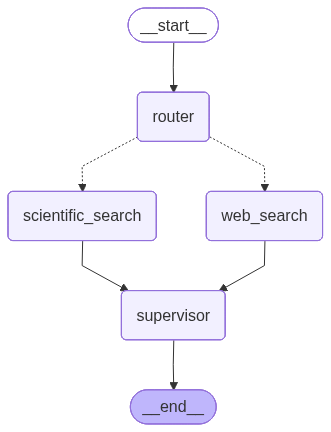

In [ ]:
Image(app.get_graph().draw_mermaid_png())

In [ ]:
resultado = app.invoke({"user_query" : "Qual as principais fontes economicas de Malta? Use apenas fontes da web"})
print(resultado["final_answer"])

## Resultados de pesquisa combinados

## Resultados de pesquisa na Web
A economia de Malta é caracterizada por ser aberta, pequena e altamente dependente do setor de serviços, dado que o país possui recursos naturais limitados e depende da importação de grande parte de seus alimentos e energia.

Com base em dados de fontes oficiais e econômicas, as principais fontes de renda de Malta são:

*   **Turismo:** É um dos pilares fundamentais da economia maltesa, atraindo milhões de visitantes anualmente devido ao seu patrimônio histórico e localização geográfica.
*   **Serviços Financeiros:** Malta consolidou-se como um centro importante para serviços financeiros, atraindo empresas e investimentos internacionais.
*   **Setor Digital e Tecnologia:** O país tem feito uma aposta estratégica no setor digital, incentivando o desenvolvimento de *start-ups* e visando o fortalecimento da sua infraestrutura tecnológica.
*   **Indústria Marítima:** O país possui uma das maiores frotas de registro de n

In [ ]:
resultado = app.invoke({"user_query" : "Qual as principais fontes economicas de Malta? Use apenas fontes cientificas"})
print(resultado["final_answer"])

## Resultados de pesquisa combinados

## Resultados de pesquisa na Web
A economia de Malta é caracterizada por ser um mercado aberto, com forte dependência do comércio exterior, turismo e serviços. Como o país possui recursos naturais limitados (produz menos de 25% de sua necessidade alimentar, tem escassez de água doce e poucas fontes de energia domésticas), sua estrutura econômica é altamente especializada.

Com base em fontes institucionais e relatórios econômicos (como o *The World Factbook* da CIA e indicadores econômicos da *Moody's Analytics*), as principais fontes econômicas de Malta são:

### 1. Setor de Serviços e Turismo
*   **Turismo:** É um dos pilares centrais da economia maltesa, contribuindo significativamente para o Produto Interno Bruto (PIB) e o emprego.
*   **Serviços Financeiros:** Malta consolidou-se como um centro financeiro importante na região, beneficiando-se da sua integração na União Europeia e da adoção do euro.
*   **Tecnologia de Informação e Jogos Online

In [ ]:
import gradio as gr

def run_graph(user_query):
  resultado = app.invoke({"user_query" : user_query})
  return resultado["final_answer"]

iface = gr.Interface(
    fn= run_graph,
    inputs= gr.Textbox(label= "Digite sua pergunta: "),
    outputs= gr.Markdown(label= "Resposta final: "),
    title= 'Agente de pesquisa',
    description= "Faça uma pergunta e obtenha uma resposta com fontes da web ou fontes cientificas"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fe7830b3091ab990b3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
